In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Add project root to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from scripts.preprocessing import AutomatedPreprocessor

# Here we import and split the data
df = pd.read_csv("../data/mock/new/data.csv")

TARGET_COLUMN = "rating"
columns_to_ignore = [TARGET_COLUMN, "timePeriod", "session_id", "sent_at", "date", "Date", "id"]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Val Shape: {X_val_processed.shape}")
print(f"Processed Test Shape: {X_test_processed.shape}")



Processed Train Shape: (1704, 9)
Processed Val Shape: (427, 9)
Processed Test Shape: (533, 9)


In [16]:
# Random Forest Classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")



Best Parameters: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}



--- Train Metrics ---
Accuracy:  0.8351
Precision (weighted): 0.8146
Recall (weighted):    0.8351
F1 Score (weighted):  0.8211

--- Test/Validation Metrics ---
Accuracy:  0.8290
Precision (weighted): 0.8068
Recall (weighted):    0.8290
F1 Score (weighted):  0.8152

--- Feature Importances (Top 20) ---
max30minLight_std30minLight                                                                 0.383362
min30minLight_mean30minLight                                                                0.215501
max30minCO2_min30minCO2_mean30minCO2_min30minHumidity_max30minHumidity_mean30minHumidity    0.096808
std30minCO2                                                                                 0.075602
min30minTemp_max30minTemp_mean30minTemp                                                     0.057100
std30minHumidity_trend30minHumidity_trend30minCO2                                           0.052068
trend30minTemp                                                                            

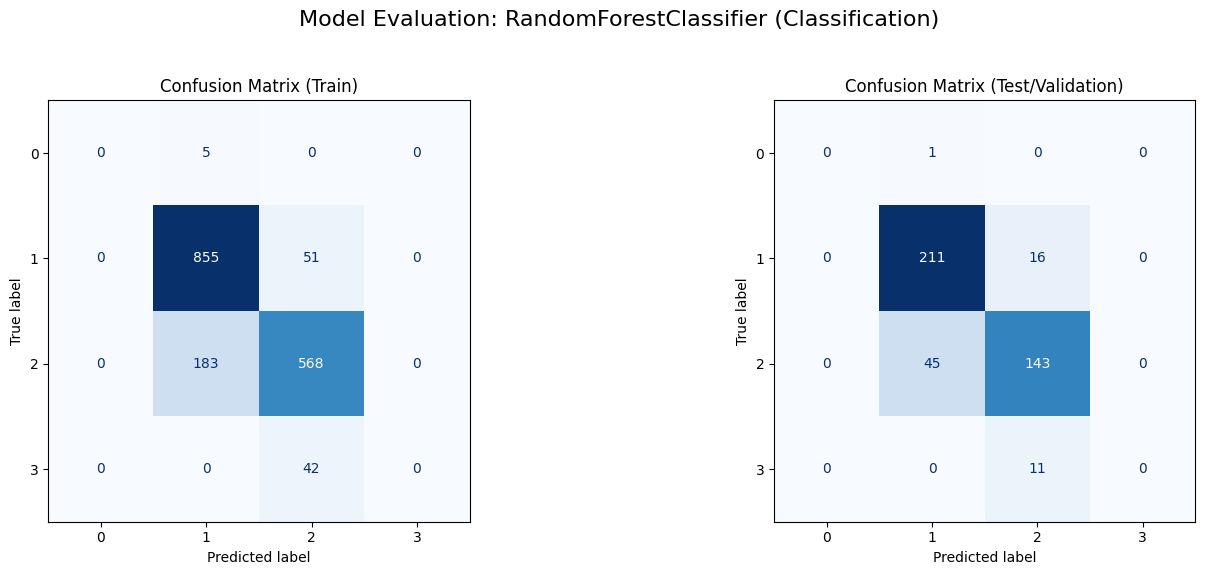

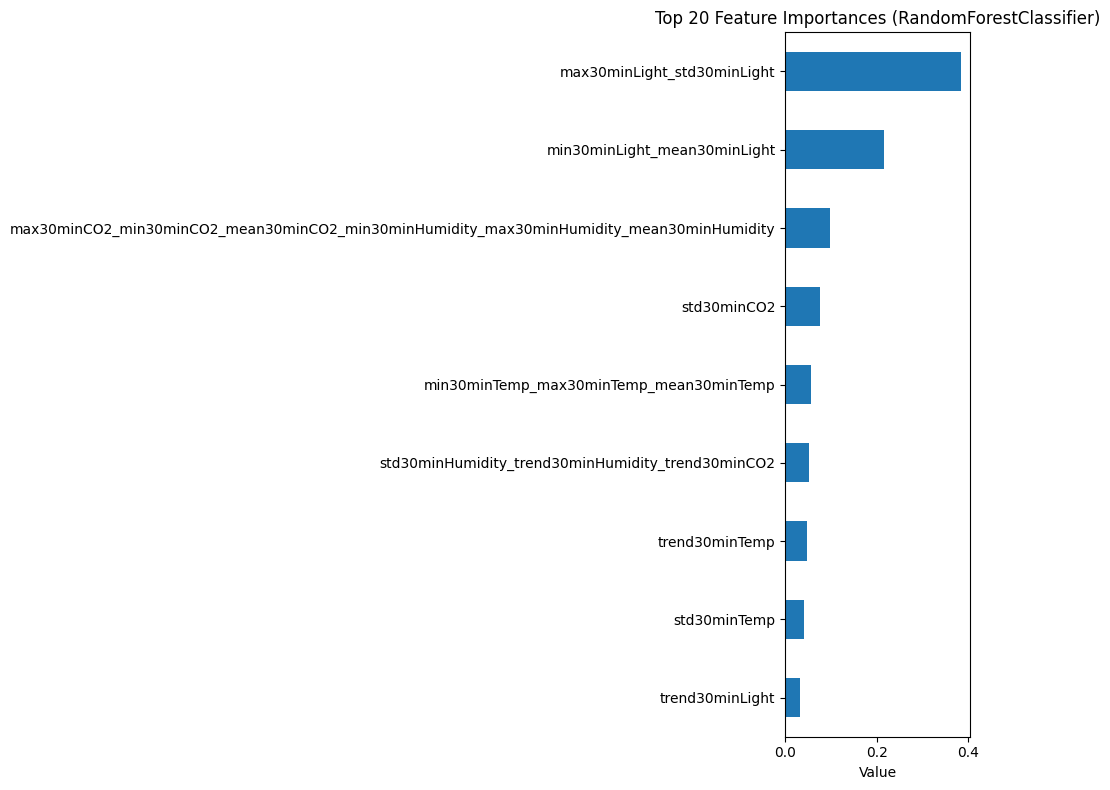

In [17]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model
best_model = RandomForestClassifier(class_weight= None, max_depth= 5, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 200)
best_model.fit(X_train_processed, y_train)


evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, True);


## Conclusion

The Random Forest Classifier currently appears to be the best choice for our prediction task.

It handles the imbalanced nature of our dataset better than the simple linear models in Notebook 5 and matches (or even exceeds) the performance of the neural networks in Notebook 4. The weighted approach (class_weight='balanced') is particularly effective at catching rare ratings without sacrificing too much overall accuracy.

Unlike the Neural Networks, the Random Forest is much less prone to overfitting on our small dataset. It also provides a clear 'Feature Importance' ranking which is very useful for our project development.

Going forward, this model strikes the best balance between performance, explainability, and ease of deployment. While Neural Networks (Notebook 4) might eventually win with more data, the Random Forest is our current champion for production use.
